<a href="https://colab.research.google.com/github/abdelrahman-elhadik/Food_Recommendation_ML/blob/main/Diet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

In [2]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download  -d  vechoo/diet-plan-recommendation

Dataset URL: https://www.kaggle.com/datasets/vechoo/diet-plan-recommendation
License(s): unknown
diet-plan-recommendation.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip /content/diet-plan-recommendation.zip

Archive:  /content/diet-plan-recommendation.zip
  inflating: Dataset.csv             


In [7]:
df = pd.read_csv("/content/Dataset.csv")
df.head(5)

,Unnamed: 0,age,weight(kg),height(m),gender,BMI,BMR,activity_level,calories_to_maintain_weight,BMI_tags,Label
0,1,2,16.097862,0.932025,F,18.531612,958.584,1.2,1150.3008,8,13
1,2,4,14.619374,0.916687,F,17.397496,932.383,1.7,1585.0511,7,1
2,4,4,17.899918,0.997288,F,17.997414,977.578,1.9,1857.3982,7,4
3,6,3,13.532880,1.022786,F,12.936609,944.689,1.9,1794.9091,7,3
4,8,4,17.039484,1.053977,M,15.338909,799.229,1.9,1518.5351,7,0


In [8]:
df = df.drop(["Unnamed: 0", "BMI_tags", "Label"], axis=1)
df = pd.get_dummies(df, columns=['gender'], drop_first=False)

In [9]:
X = df.drop(['calories_to_maintain_weight'], axis=1)
Y = df['calories_to_maintain_weight']

In [10]:
print(X.head())
print(Y.head())

   age  weight(kg)  height(m)        BMI      BMR  activity_level  gender_F  \
0    2   16.097862   0.932025  18.531612  958.584             1.2      True   
1    4   14.619374   0.916687  17.397496  932.383             1.7      True   
2    4   17.899918   0.997288  17.997414  977.578             1.9      True   
3    3   13.532880   1.022786  12.936609  944.689             1.9      True   
4    4   17.039484   1.053977  15.338909  799.229             1.9     False   

   gender_M  
0     False  
1     False  
2     False  
3     False  
4      True  
0    1150.3008
1    1585.0511
2    1857.3982
3    1794.9091
4    1518.5351
Name: calories_to_maintain_weight, dtype: float64


In [11]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)


In [12]:
modelLR = LinearRegression()
modelLR.fit(X_train, Y_train)
Y_pred = modelLR.predict(X_test)


In [13]:

mse = mean_squared_error(Y_test, Y_pred)
print(f'Mean Squared Error: {mse}')
accuracy = modelLR.score(X_test, Y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')


Mean Squared Error: 1966.0291331480473
Accuracy: 98.74%


In [14]:
def calculate_bmi(weight_kg, height_m):
    return weight_kg / (height_m ** 2)

def calculate_bmr(age, weight_kg, height_m, gender_F, gender_M):
    if gender_F == 1:  # Female
        return 655 + (9.6 * weight_kg) + (1.8 * height_m * 100) - (4.7 * age)
    elif gender_M == 1:  # Male
        return 66 + (13.7 * weight_kg) + (5 * height_m * 100) - (6.8 * age)
    else:
        raise ValueError("Invalid gender values")

def calculate_daily_calories_direct(user_inputs, initial_weight, desired_weight, time_interval, modelLR):
    # Extract user inputs
    age = user_inputs['age']
    weight_kg = user_inputs['weight(kg)']
    height_m = user_inputs['height(m)']
    gender_F = user_inputs['gender_F']
    gender_M = user_inputs['gender_M']
    activity_level = user_inputs['activity_level']

    # Calculate BMI and BMR using the provided formulas
    BMI = calculate_bmi(weight_kg, height_m)
    BMR = calculate_bmr(age, weight_kg, height_m, gender_F, gender_M)

    # Calculate total weight change
    weight_change = desired_weight - initial_weight
    calories_per_kg = 7700

    daily_weight_change =(weight_change) / (time_interval)
    # Estimated calories per kg change (adjust as needed)


    # Calculate caloric difference based on weight change goal
    caloric_difference = daily_weight_change * calories_per_kg

    # Create input array for model prediction
    input_array = np.array([[age, weight_kg, height_m, BMI, BMR, activity_level, gender_F, gender_M]])

    # Use the trained model to predict daily maintenance calories
    model_predicted_calories = modelLR.predict(input_array)
    print(model_predicted_calories)
    # Sum the model predicted calories and caloric difference
    daily_cal = model_predicted_calories + caloric_difference

    return daily_cal

In [15]:
# Example usage
user_inputs = {
    'age': 25,
    'weight(kg)': 70,
    'height(m)': 1.75,
    'gender_F': 0,  # Female
    'gender_M': 1,  # Male
    'activity_level': 1.5  # Moderate activity level (replace with user input)
}

initial_weight = 100  # replace with user input
desired_weight = 80  # replace with user input
time_interval_days = 2000  # replace with user input

# Assume 'model' is your trained machine learning model
daily_calorie_difference_direct = calculate_daily_calories_direct(user_inputs, initial_weight, desired_weight, time_interval_days, modelLR)

# Display the result
print(f"Estimated Daily Caloric Intake for Weight Change: {daily_calorie_difference_direct[0]:.2f} calories")

[2546.6728392]
Estimated Daily Caloric Intake for Weight Change: 2469.67 calories


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##part2

In [16]:
!kaggle datasets download  -d  vaishnavivenkatesan/food-and-their-calories

Dataset URL: https://www.kaggle.com/datasets/vaishnavivenkatesan/food-and-their-calories
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
  0% 0.00/6.59k [00:00<?, ?B/s]
100% 6.59k/6.59k [00:00<00:00, 22.1MB/s]


In [17]:
!kaggle datasets download  -d shuyangli94/food-com-recipes-and-user-interactions

Dataset URL: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions
License(s): copyright-authors
 80% 214M/267M [00:00<00:00, 570MB/s] 
100% 267M/267M [00:00<00:00, 334MB/s]


In [18]:
!unzip /content/food-and-their-calories.zip

Archive:  /content/food-and-their-calories.zip
  inflating: Food and Calories - Sheet1.csv  


In [19]:
!unzip /content/food-com-recipes-and-user-interactions.zip

Archive:  /content/food-com-recipes-and-user-interactions.zip
  inflating: PP_recipes.csv          
  inflating: PP_users.csv            
  inflating: RAW_interactions.csv    
  inflating: RAW_recipes.csv         
  inflating: ingr_map.pkl            
  inflating: interactions_test.csv   
  inflating: interactions_train.csv  
  inflating: interactions_validation.csv  


In [20]:
food_df = pd.read_csv('/content/RAW_recipes.csv')
food_df.head(5)

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [21]:
# Extract unique food names
unique_food_names = food_df['name'].unique()
# Print the total number of unique food names
total_unique_food_names = len(unique_food_names)
print("Total Unique Food Names:", total_unique_food_names)

# Print the top 100 unique food names
print("\nTop 100 Unique Food Names:")
for food_name in unique_food_names[:100]:
    print(food_name)

Total Unique Food Names: 230186

Top 100 Unique Food Names:
arriba   baked winter squash mexican style
a bit different  breakfast pizza
all in the kitchen  chili
alouette  potatoes
amish  tomato ketchup  for canning
apple a day  milk shake
aww  marinated olives
backyard style  barbecued ribs
bananas 4 ice cream  pie
beat this  banana bread
berry  good sandwich spread
better than sex  strawberries
better then bush s  baked beans
boat house  collard greens
calm your nerves  tonic
chicken lickin  good  pork chops
chile rellenos
chinese  candy
chinese  chop suey
cream  of cauliflower soup  vegan
cream  of spinach soup
cream  of spinach soup  vegan
crispy crunchy  chicken
deep fried dessert thingys
easiest ever  hollandaise sauce
emotional balance  spice mixture
fool the meat eaters  chili
forgotten  minestrone
fried  potatoes
george s at the cove  black bean soup
get the sensation  brownies
global gourmet  taco casserole
grilled  ranch bread
grilled  venison burgers
healthy for them  yogur

In [22]:
# DIRECT K MEANS CLUSTERING APPROACH.
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

food_df = pd.read_csv('/content/RAW_recipes.csv')
def preprocess_data(df):
    df[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']] = df['nutrition'].str.split(",", expand=True)
    df['calories'] = df['calories'].apply(lambda x: x.replace('[',''))
    df['carbohydrates (PDV)'] = df['carbohydrates (PDV)'].apply(lambda x: x.replace(']',''))
    df[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']] = df[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']].astype('float')

    df.drop(['id', 'contributor_id', 'submitted', 'tags', 'nutrition'], axis=1, inplace=True)


    df['food types'] = np.nan
    df['food types'] = df['food types'].astype('str')

    for i in df.index:
        if 'eggs' not in df.loc[i, 'ingredients']:
            if 'ice-cream' in df.loc[i, 'ingredients'] or 'chocolate' in df.loc[i, 'ingredients'] or 'cookies' in df.loc[i, 'ingredients']:
                df.loc[i, 'food types'] = 'Veg dessert'
        elif 'eggs' in df.loc[i, 'ingredients']:
            if 'ice-cream' in df.loc[i, 'ingredients'] or 'chocolate' in df.loc[i, 'ingredients'] or 'cookies' in df.loc[i, 'ingredients']:
                df.loc[i, 'food types'] = 'Non-Veg dessert'

    for i in df.index:
        if df.loc[i, 'food types'] != 'Veg dessert' and df.loc[i, 'food types'] != 'Non-Veg dessert' and 20 < df.loc[i, 'calories'] < 300:
            df.loc[i, 'food types'] = 'Healthy'

    for i in df.index:
        if df.loc[i, 'food types'] != 'Veg dessert' and df.loc[i, 'food types'] != 'Non-Veg dessert' and df.loc[i, 'food types'] != 'Healthy':
            if 'chicken' in df.loc[i, 'ingredients'] or 'eggs' in df.loc[i, 'ingredients'] or 'ham' in df.loc[i, 'ingredients'] or 'pepperoni' in df.loc[i, 'ingredients']:
                df.loc[i, 'food types'] = 'Non-veg'

    for i in df.index:
        if df.loc[i, 'food types'] != 'Veg dessert' and df.loc[i, 'food types'] != 'Non-Veg dessert' and df.loc[i, 'food types'] != 'Healthy' and df.loc[i, 'food types'] != 'Non-veg':
            df.loc[i, 'food types'] = 'Veg'

    df['food types'].value_counts()
    df['food types'].isnull().sum()

    return df

# Apply the function to your dataframe
food_df = preprocess_data(food_df)
food_df.head()

# One-hot encode food types
types = pd.get_dummies(food_df['food types'])
food_df = pd.concat([food_df, types], axis=1)

# Create a pivot table for nutrient details
cal = food_df.pivot_table(columns='name', values=['total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)'])

# Apply K-Means clustering
columns_for_clustering = ['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)']
clustering_data = food_df[columns_for_clustering]
scaler = StandardScaler()
clustering_data_standardized = scaler.fit_transform(clustering_data)

kmeans = KMeans(n_clusters=2000, n_init=10, random_state=42)
food_df['cluster'] = kmeans.fit_predict(clustering_data_standardized)
print(food_df.head(5))

                                         name  minutes  n_steps  \
0  arriba   baked winter squash mexican style       55       11   
1            a bit different  breakfast pizza       30        9   
2                   all in the kitchen  chili      130        6   
3                          alouette  potatoes       45       11   
4          amish  tomato ketchup  for canning      190        5   

                                               steps  \
0  ['make a choice and proceed with recipe', 'dep...   
1  ['preheat oven to 425 degrees f', 'press dough...   
2  ['brown ground beef in large pot', 'add choppe...   
3  ['place potatoes in a large pot of lightly sal...   
4  ['mix all ingredients& boil for 2 1 / 2 hours ...   

                                         description  \
0  autumn is my favorite time of year to cook! th...   
1  this recipe calls for the crust to be prebaked...   
2  this modified version of 'mom's' chili was a h...   
3  this is a super easy, great tasti

In [23]:
cluster_counts = food_df['cluster'].value_counts()

# Display the number of elements in each cluster
print("Number of elements in each cluster:")
print(cluster_counts.head(50))

Number of elements in each cluster:
cluster
930     4757
154     3013
1529    2643
800     2553
1958    2396
1859    2202
80      2096
1652    2088
1855    1972
1531    1761
1409    1702
646     1685
376     1606
1473    1598
578     1553
739     1471
1687    1435
811     1422
275     1392
1125    1378
606     1322
1312    1302
529     1247
146     1244
375     1171
834     1166
441     1136
1259    1117
464     1110
1561    1088
1725    1072
1653    1046
1745    1009
1777     997
93       987
1916     967
554      964
905      959
1517     947
14       929
528      928
1901     917
360      915
1931     911
807      871
889      850
49       847
729      843
514      840
1609     826
Name: count, dtype: int64


In [24]:
# Plot Pie Chart Function
# -----------------------------
def plot_pie_chart(ax, data, labels):
    ax.pie(data, labels=labels, autopct='%1.1f%%', startangle=90,
           colors=['#99ff99', '#ffcc99', '#ccffcc', '#ff6666', '#c2f0c2'])
    ax.axis('equal')
    ax.set_facecolor('#1a1a1a')

In [28]:
# -----------------------------
# Find Closest Food Function
# -----------------------------
def find_closest_food(target_food, target_features, exclude_foods=[]):
    recommended_items = []

    target_cluster_df = food_df.loc[food_df['name'] == target_food, 'cluster']
    if target_cluster_df.empty:
        return recommended_items

    target_cluster = target_cluster_df.values[0]

    cluster_recipes = food_df[food_df['cluster'] == target_cluster]
    cluster_recipes = cluster_recipes[~cluster_recipes['name'].isin(exclude_foods)]

    if cluster_recipes.empty:
        return recommended_items

    # 🔥 التحويل المهم
    cluster_values = cluster_recipes[columns_for_clustering].values.astype(float)
    target_values = target_features.astype(float).reshape(1, -1)

    distances = np.linalg.norm(cluster_values - target_values, axis=1)

    cluster_recipes = cluster_recipes.copy()
    cluster_recipes['distance_to_target'] = distances

    closest_recipes = cluster_recipes.sort_values('distance_to_target').head(5)
    recommended_items.append(closest_recipes)

    return recommended_items

In [29]:
# -----------------------------
# Meal Time Rules
# -----------------------------
meal_time_rules = {
    'Breakfast': {'protein_min':15, 'calories_max':500, 'fat_max':15},
    'Mid_Morning_Snack': {'calories_max':300},
    'Lunch': {'protein_min':20, 'calories_min':500, 'calories_max':800},
    'Evening_Snack': {'calories_max':300},
    'Dinner': {'calories_max':600, 'carbs_max':40}
}

def pick_meal_by_time(meal_time):
    rules = meal_time_rules[meal_time]
    df = food_df.copy()

    # Filter by meal time rules
    if 'protein_min' in rules:
        df = df[df['protein (PDV)'] >= rules['protein_min']]
    if 'calories_min' in rules:
        df = df[df['calories'] >= rules['calories_min']]
    if 'calories_max' in rules:
        df = df[df['calories'] <= rules['calories_max']]
    if 'fat_max' in rules:
        df = df[df['total fat (PDV)'] <= rules['fat_max']]
    if 'carbs_max' in rules:
        df = df[df['carbohydrates (PDV)'] <= rules['carbs_max']]

    if df.empty:
        return None
    return df.sample(1).iloc[0]


🍽 Breakfast
Recommended: homemade condensed milk | Calories: 252.8


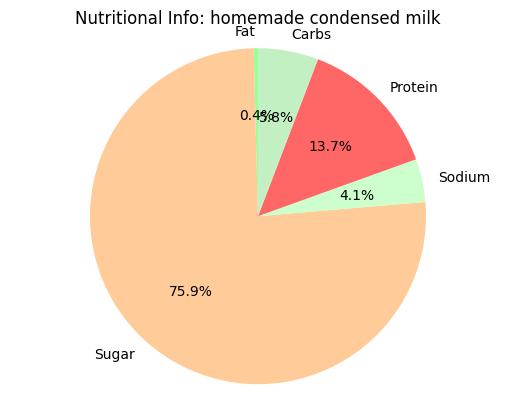


🍽 Mid_Morning_Snack
Recommended: gorgonzola and olive stuffed grape leaves | Calories: 78.8


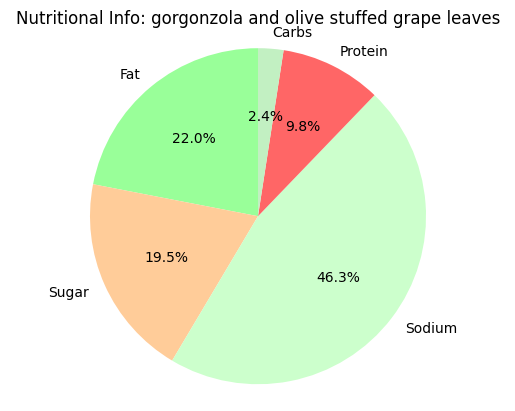


🍽 Lunch
Recommended: easy pork chops | Calories: 541.3


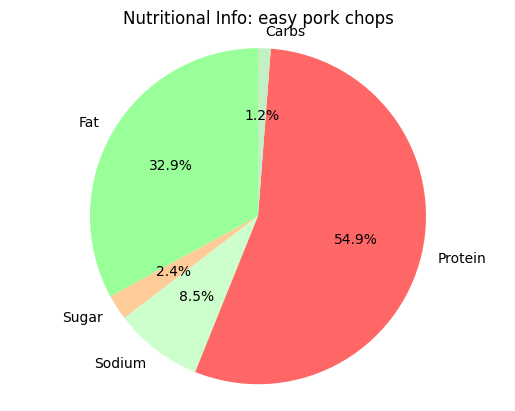


🍽 Evening_Snack
Recommended: 15 minute vanilla rice pudding | Calories: 222.8


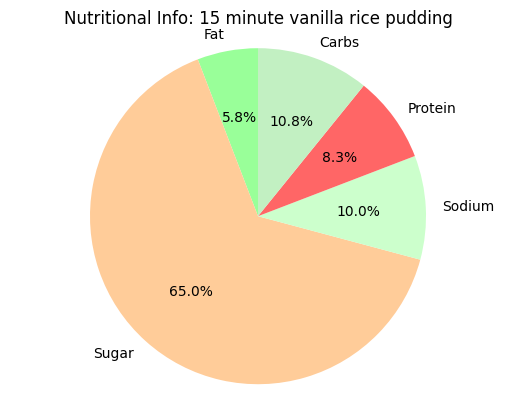


🍽 Dinner
Recommended: herb rubbed bison sirlion tip roast | Calories: 339.5


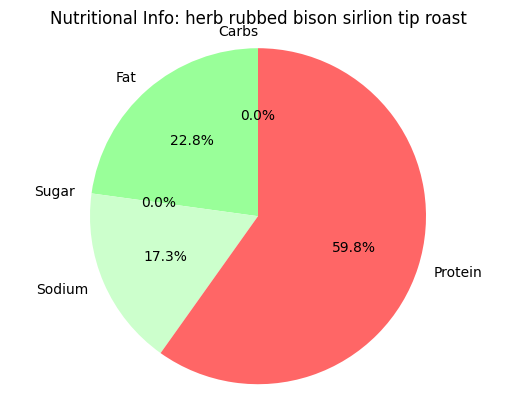

In [30]:
# -----------------------------
# Generate Recommendations
# -----------------------------
meal_times = ['Breakfast', 'Mid_Morning_Snack', 'Lunch', 'Evening_Snack', 'Dinner']
selected_foods = []
lose_weight = 1

for meal_time in meal_times:
    print(f"\n🍽 {meal_time}")

    picked_food = pick_meal_by_time(meal_time)
    if picked_food is None:
        print("No suitable food found")
        continue

    target_food = picked_food['name']
    target_features = picked_food[columns_for_clustering].values
    recommendations = find_closest_food(target_food, target_features, exclude_foods=selected_foods)

    if not recommendations:
        print("No recommendations found")
        continue

    selected_foods.extend(recommendations[0]['name'].tolist())

    # Choose best recommendation
    if lose_weight:
        best = recommendations[0].sort_values('calories').head(1)
    else:
        best = recommendations[0].sort_values('calories', ascending=False).head(1)

    for _, row in best.iterrows():
        print(f"Recommended: {row['name']} | Calories: {row['calories']}")

        fig, ax = plt.subplots()
        nutritional_data = [
            row['total fat (PDV)'], row['sugar (PDV)'], row['sodium (PDV)'],
            row['protein (PDV)'], row['carbohydrates (PDV)']
        ]
        labels = ['Fat', 'Sugar', 'Sodium', 'Protein', 'Carbs']
        plot_pie_chart(ax, nutritional_data, labels)
        plt.title(f"Nutritional Info: {row['name']}")
        plt.show()